# Exploratory Data Analysis — Office Furniture E-commerce

**Objective:** Understand sales patterns, customer behavior, and identify key drivers of revenue and cancellations.

**Dataset:** 9,999 orders from Sep 2023 – Sep 2024 across 13 office furniture products.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv("../data/processed/fact_orders.csv", parse_dates=["order_date"])
print(f"Shape: {df.shape}")
df.head()

Shape: (9999, 22)


,order_id,customer_id,product_id,order_status,payment_id,order_date,shipping_id,is_old_customer,feedback,quantity,...,gender,sku,product_type,unit_price,payment_method,payment_type,shipping_type,shipping_category,shipping_cost_level,revenue
0,1,1000,CHR102,Cancelled,3,2024-03-20,1,False,2,7,...,Male,OFFICECHAIR_CHR102,Office Chair,596.09,Credit Card,Online,Standard,Standard,Low,4172.63
1,2,1000,SCB101,Completed,5,2024-04-20,4,False,3,3,...,Male,STORAGECAB_SCB101,Storage Cabinet,366.98,Paypal,Online,Overnight,Fast Shipping,Very High,1100.94
2,3,1002,DSK103,Completed,3,2023-10-17,3,False,3,4,...,Male,OFFICEDESK_DSK103,Office Desk,691.88,Credit Card,Online,Express,Fast Shipping,High,2767.52
3,4,1002,CHR102,Completed,2,2024-08-09,4,True,2,4,...,Male,OFFICECHAIR_CHR102,Office Chair,596.09,Cash,Offline,Overnight,Fast Shipping,Very High,2384.36
4,5,1003,CHR101,Completed,2,2024-05-21,3,True,5,2,...,Male,OFFICECHAIR_CHR101,Office Chair,488.35,Cash,Offline,Express,Fast Shipping,High,976.70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             9999 non-null   int64         
 1   customer_id          9999 non-null   int64         
 2   product_id           9999 non-null   object        
 3   order_status         9999 non-null   object        
 4   payment_id           9999 non-null   int64         
 5   order_date           9999 non-null   datetime64[ns]
 6   shipping_id          9999 non-null   int64         
 7   is_old_customer      9999 non-null   bool          
 8   feedback             9999 non-null   int64         
 9   quantity             9999 non-null   int64         
 10  cost                 9999 non-null   float64       
 11  age                  9999 non-null   int64         
 12  gender               9999 non-null   object        
 13  sku                  9999 non-nul

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,9999.0,NaN,NaN,NaN,5000.0,1.0,2500.5,5000.0,7499.5,9999.0,2886.607005
customer_id,9999.0,NaN,NaN,NaN,5494.858886,1000.0,3271.0,5478.0,7765.0,9998.0,2601.896966
product_id,9999,8,SCB101,2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,9999,5,Completed,6695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_id,9999.0,NaN,NaN,NaN,3.50085,2.0,3.0,3.0,5.0,5.0,1.118581
order_date,9999,NaN,NaN,NaN,2024-03-23 16:14:50.009000960,2023-09-24 00:00:00,2023-12-23 00:00:00,2024-03-24 00:00:00,2024-06-22 00:00:00,2024-09-23 00:00:00,NaN
shipping_id,9999.0,NaN,NaN,NaN,2.680268,1.0,1.0,3.0,4.0,4.0,1.242816
is_old_customer,9999,2,False,7851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feedback,9999.0,NaN,NaN,NaN,3.192719,1.0,3.0,3.0,3.0,5.0,0.977013
quantity,9999.0,NaN,NaN,NaN,5.443044,1.0,3.0,5.0,8.0,10.0,2.877114


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

## 2. KPI Overview

High-level metrics matching the Power BI dashboard.

In [6]:
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
total_revenue = df.loc[df["order_status"] == "Completed", "revenue"].sum()
completion_rate = (df["order_status"] == "Completed").mean() * 100
avg_feedback = df["feedback"].mean()

print(f"Total Orders:      {total_orders:,}")
print(f"Total Customers:   {total_customers:,}")
print(f"Total Revenue:     ${total_revenue:,.0f}")
print(f"Completion Rate:   {completion_rate:.2f}%")
print(f"Avg Feedback:      {avg_feedback:.2f} / 5")

Total Orders:      9,999
Total Customers:   6,128
Total Revenue:     $16,528,906
Completion Rate:   66.96%
Avg Feedback:      3.19 / 5


## 3. Order Status Distribution

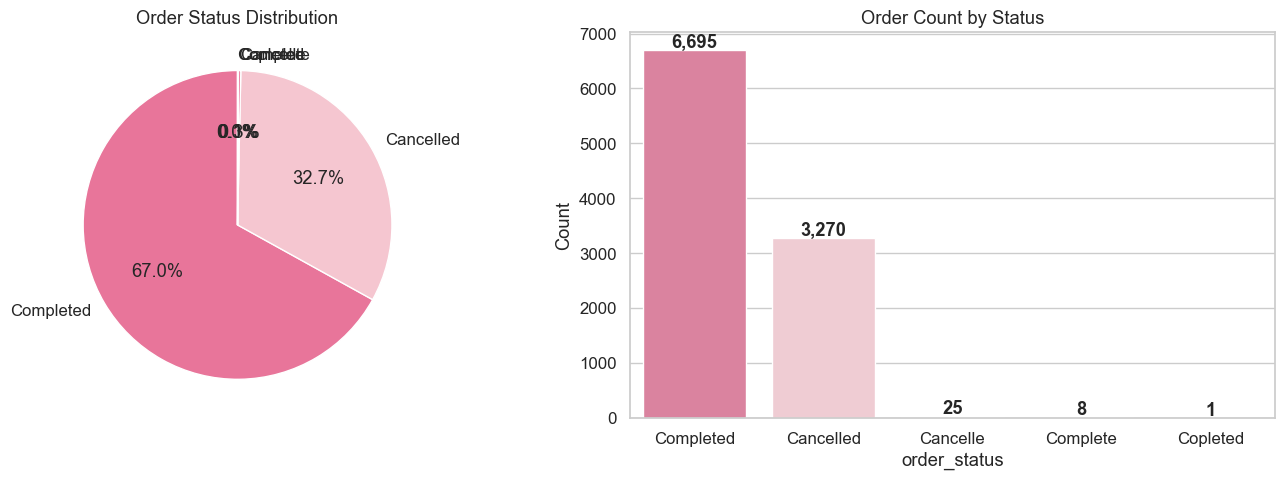

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = df["order_status"].value_counts()
colors = ["#e8759a", "#f5c6d0"]

# Pie chart
axes[0].pie(
    status_counts, labels=status_counts.index, autopct="%1.1f%%",
    colors=colors, startangle=90, wedgeprops={"edgecolor": "white"}
)
axes[0].set_title("Order Status Distribution")

# Bar chart
sns.barplot(x=status_counts.index, y=status_counts.values, palette=colors, ax=axes[1])
axes[1].set_title("Order Count by Status")
axes[1].set_ylabel("Count")
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Revenue Analysis

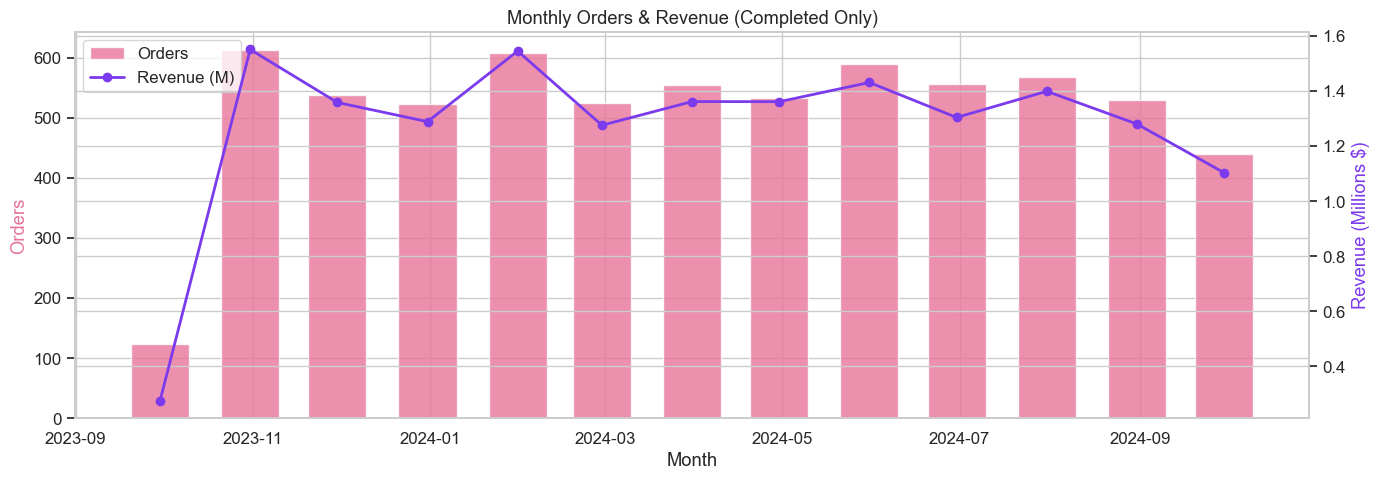

In [8]:
completed = df[df["order_status"] == "Completed"].copy()

monthly = (
    completed
    .set_index("order_date")
    .resample("M")
    .agg(orders=("order_id", "count"), revenue=("revenue", "sum"), customers=("customer_id", "nunique"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly["order_date"], monthly["orders"], width=20, color="#e8759a", alpha=0.8, label="Orders")
ax2.plot(monthly["order_date"], monthly["revenue"] / 1e6, color="#7c3aed", marker="o", linewidth=2, label="Revenue (M)")

ax1.set_xlabel("Month")
ax1.set_ylabel("Orders", color="#e8759a")
ax2.set_ylabel("Revenue (Millions $)", color="#7c3aed")
ax1.set_title("Monthly Orders & Revenue (Completed Only)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

## 5. Product Performance

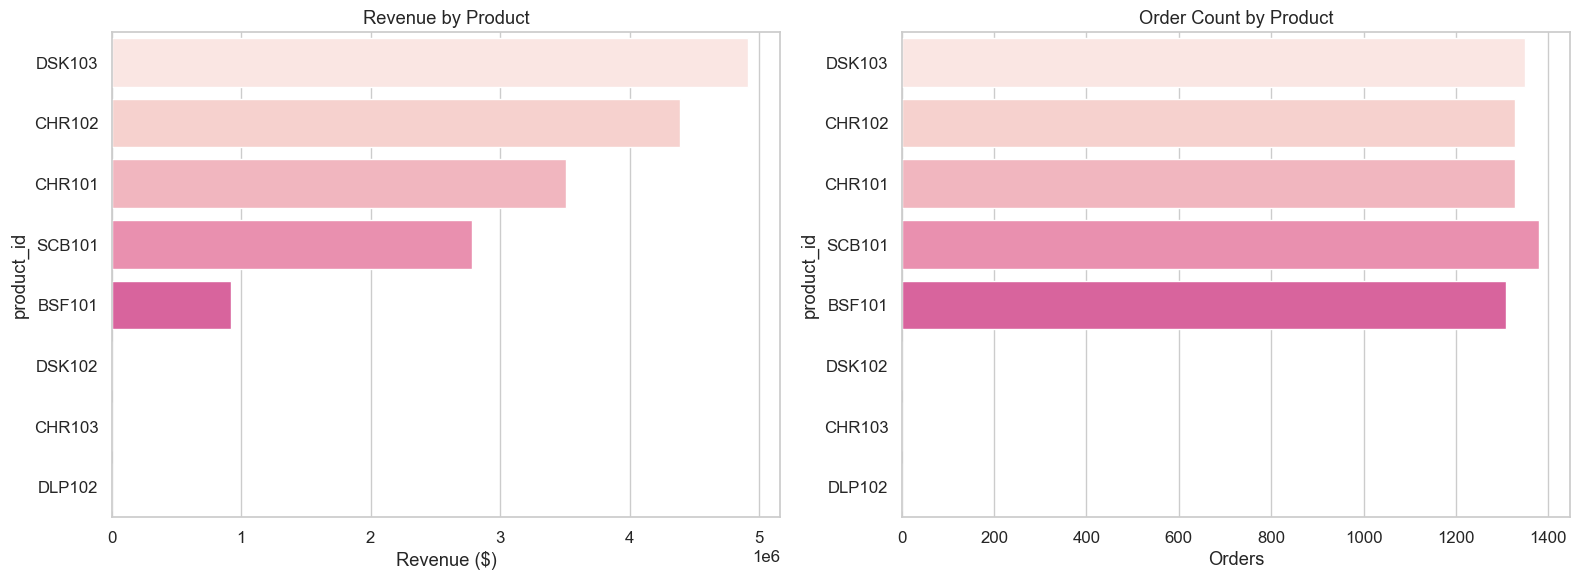

In [9]:
product_perf = (
    completed
    .groupby(["product_id", "product_type"])
    .agg(total_orders=("order_id", "count"), total_revenue=("revenue", "sum"), avg_qty=("quantity", "mean"))
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=product_perf, y="product_id", x="total_revenue", palette="RdPu", ax=axes[0])
axes[0].set_title("Revenue by Product")
axes[0].set_xlabel("Revenue ($)")

sns.barplot(data=product_perf, y="product_id", x="total_orders", palette="RdPu", ax=axes[1])
axes[1].set_title("Order Count by Product")
axes[1].set_xlabel("Orders")

plt.tight_layout()
plt.show()

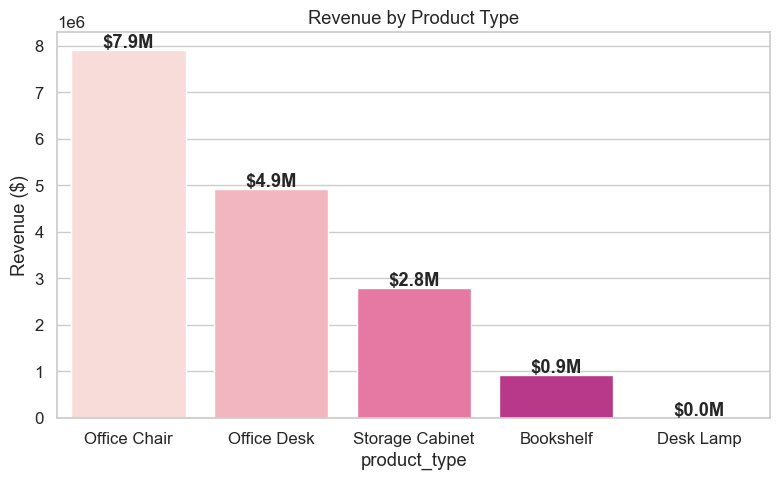

In [10]:
type_perf = (
    completed
    .groupby("product_type")
    .agg(total_orders=("order_id", "count"), total_revenue=("revenue", "sum"))
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=type_perf, x="product_type", y="total_revenue", palette="RdPu", ax=ax)
ax.set_title("Revenue by Product Type")
ax.set_ylabel("Revenue ($)")
for i, row in type_perf.iterrows():
    ax.text(type_perf.index.get_loc(i), row["total_revenue"] + 50000, f"${row['total_revenue']/1e6:.1f}M", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Cancellation Analysis

Understanding which factors drive order cancellations.

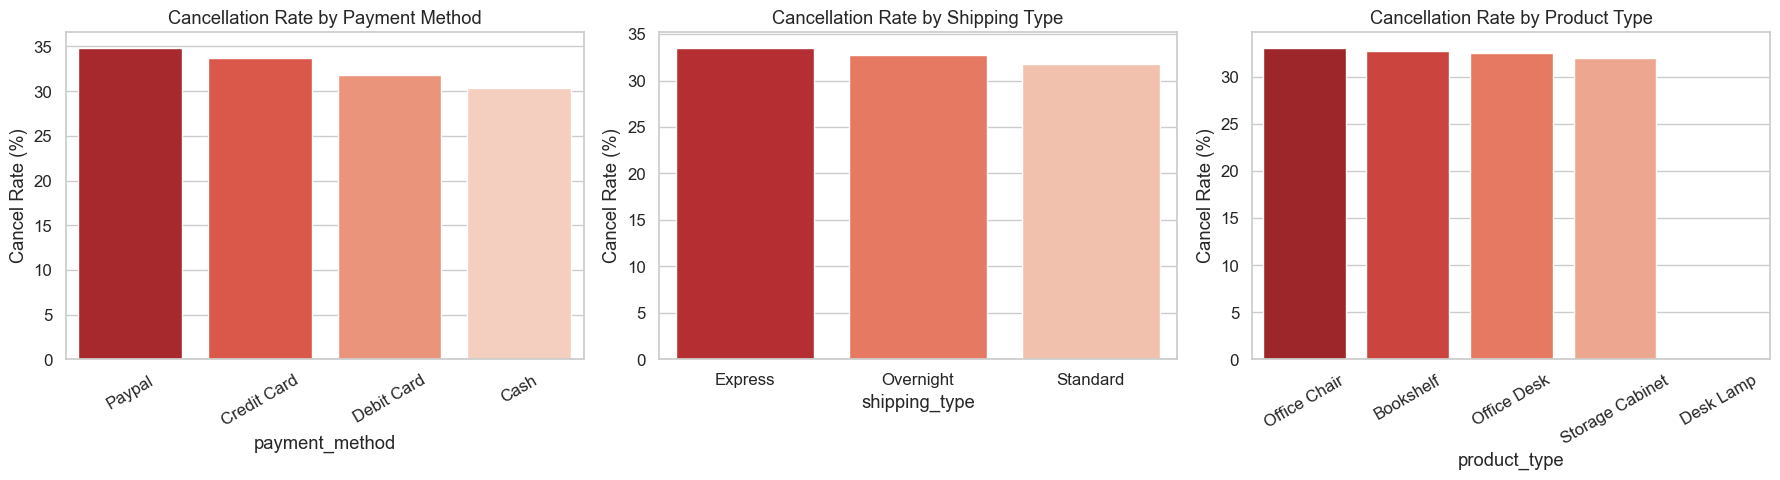

In [11]:
cancel_by_payment = (
    df.groupby("payment_method")["order_status"]
    .apply(lambda x: (x == "Cancelled").mean() * 100)
    .reset_index(name="cancel_rate")
    .sort_values("cancel_rate", ascending=False)
)

cancel_by_shipping = (
    df.groupby("shipping_type")["order_status"]
    .apply(lambda x: (x == "Cancelled").mean() * 100)
    .reset_index(name="cancel_rate")
    .sort_values("cancel_rate", ascending=False)
)

cancel_by_product = (
    df.groupby("product_type")["order_status"]
    .apply(lambda x: (x == "Cancelled").mean() * 100)
    .reset_index(name="cancel_rate")
    .sort_values("cancel_rate", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=cancel_by_payment, x="payment_method", y="cancel_rate", palette="Reds_r", ax=axes[0])
axes[0].set_title("Cancellation Rate by Payment Method")
axes[0].set_ylabel("Cancel Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=cancel_by_shipping, x="shipping_type", y="cancel_rate", palette="Reds_r", ax=axes[1])
axes[1].set_title("Cancellation Rate by Shipping Type")
axes[1].set_ylabel("Cancel Rate (%)")

sns.barplot(data=cancel_by_product, x="product_type", y="cancel_rate", palette="Reds_r", ax=axes[2])
axes[2].set_title("Cancellation Rate by Product Type")
axes[2].set_ylabel("Cancel Rate (%)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 7. Customer Demographics

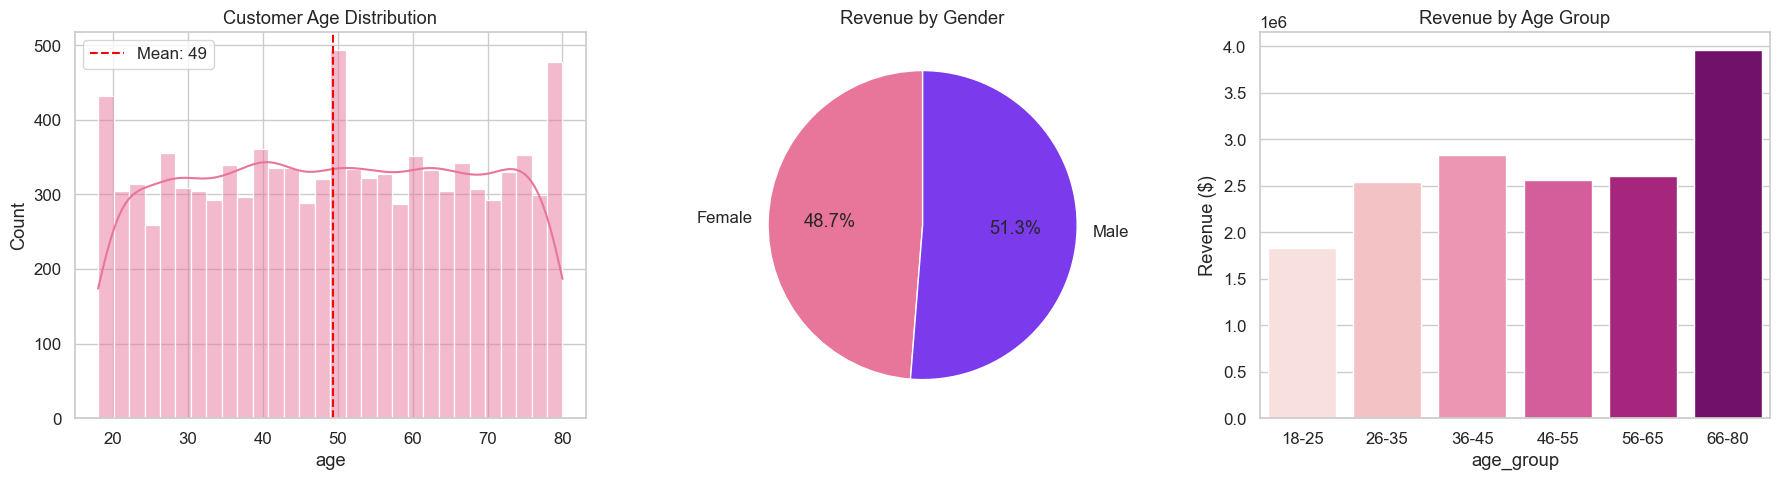

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
sns.histplot(df["age"].dropna(), bins=30, kde=True, color="#e8759a", ax=axes[0])
axes[0].set_title("Customer Age Distribution")
axes[0].axvline(df["age"].mean(), color="red", linestyle="--", label=f"Mean: {df['age'].mean():.0f}")
axes[0].legend()

# Gender split
gender_rev = completed.groupby("gender")["revenue"].sum().reset_index()
axes[1].pie(gender_rev["revenue"], labels=gender_rev["gender"], autopct="%1.1f%%",
            colors=["#e8759a", "#7c3aed"], startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Revenue by Gender")

# Age group revenue
df["age_group"] = pd.cut(df["age"], bins=[18, 25, 35, 45, 55, 65, 80], labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-80"])
age_rev = completed.assign(age_group=pd.cut(completed["age"], bins=[18, 25, 35, 45, 55, 65, 80], labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-80"]))
age_rev = age_rev.groupby("age_group", observed=True)["revenue"].sum().reset_index()
sns.barplot(data=age_rev, x="age_group", y="revenue", palette="RdPu", ax=axes[2])
axes[2].set_title("Revenue by Age Group")
axes[2].set_ylabel("Revenue ($)")

plt.tight_layout()
plt.show()

## 8. Shipping & Payment Analysis

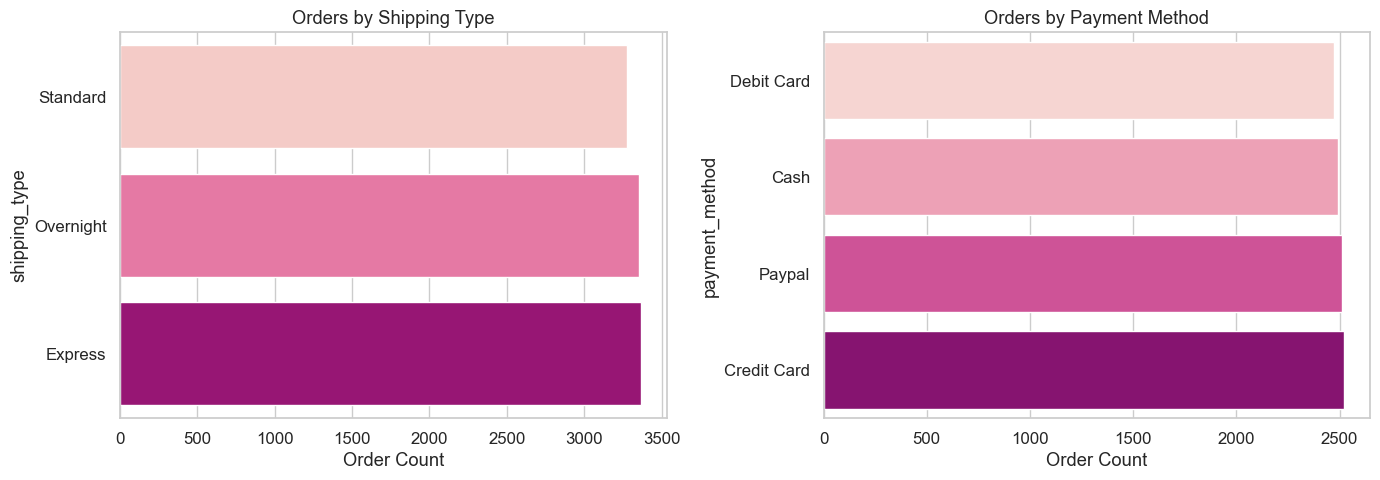

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ship_orders = df.groupby("shipping_type")["order_id"].count().sort_values(ascending=True).reset_index()
sns.barplot(data=ship_orders, y="shipping_type", x="order_id", palette="RdPu", ax=axes[0])
axes[0].set_title("Orders by Shipping Type")
axes[0].set_xlabel("Order Count")

pay_orders = df.groupby("payment_method")["order_id"].count().sort_values(ascending=True).reset_index()
sns.barplot(data=pay_orders, y="payment_method", x="order_id", palette="RdPu", ax=axes[1])
axes[1].set_title("Orders by Payment Method")
axes[1].set_xlabel("Order Count")

plt.tight_layout()
plt.show()

## 9. Feedback Analysis

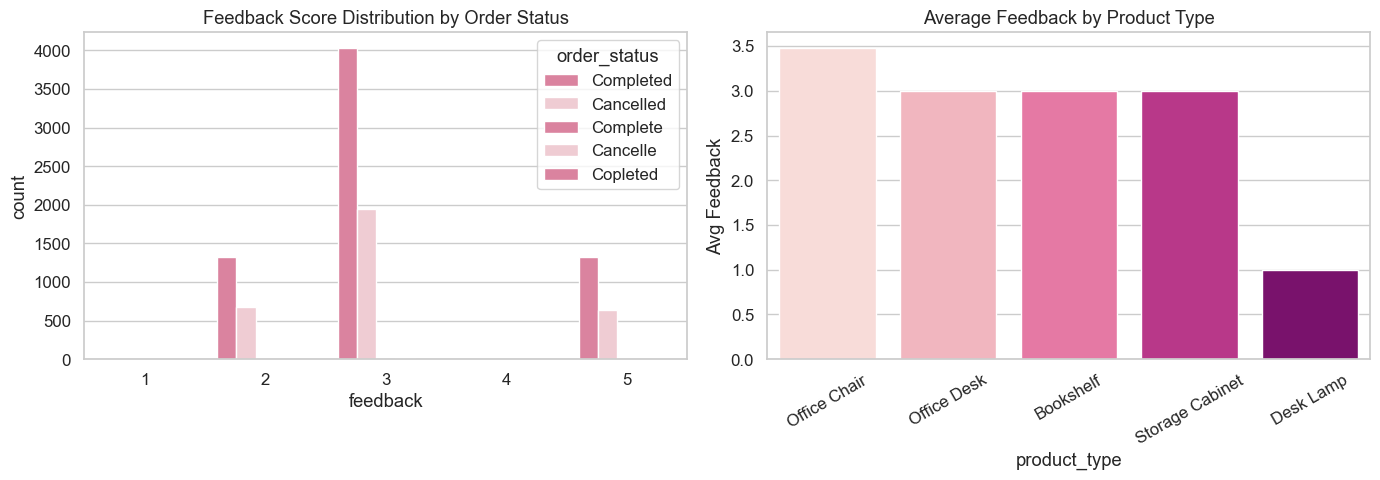

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="feedback", hue="order_status", palette=["#e8759a", "#f5c6d0"], ax=axes[0])
axes[0].set_title("Feedback Score Distribution by Order Status")

feedback_by_product = df.groupby("product_type")["feedback"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=feedback_by_product, x="product_type", y="feedback", palette="RdPu", ax=axes[1])
axes[1].set_title("Average Feedback by Product Type")
axes[1].set_ylabel("Avg Feedback")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 10. Correlation Heatmap

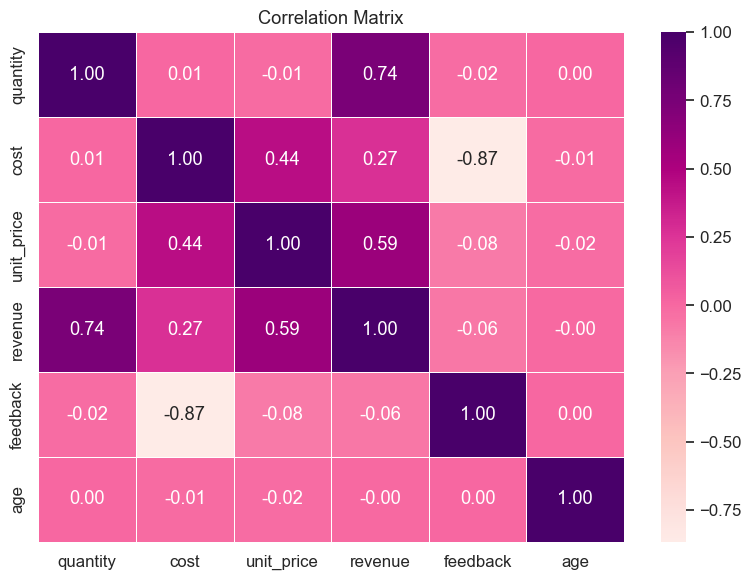

In [15]:
numeric_cols = ["quantity", "cost", "unit_price", "revenue", "feedback", "age"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdPu", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 11. Old vs New Customer Comparison

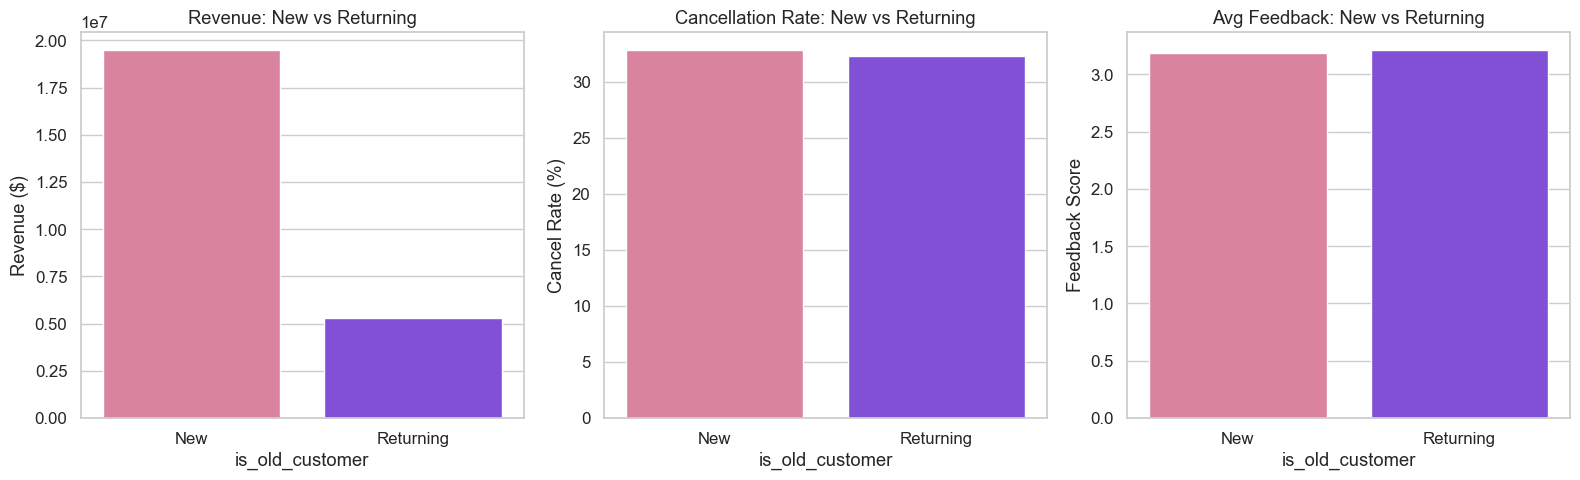

In [16]:
old_new = (
    df.groupby("is_old_customer")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue=("revenue", "sum"),
        avg_feedback=("feedback", "mean"),
        cancel_rate=("order_status", lambda x: (x == "Cancelled").mean() * 100),
    )
    .reset_index()
)
old_new["is_old_customer"] = old_new["is_old_customer"].map({True: "Returning", False: "New"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=old_new, x="is_old_customer", y="total_revenue", palette=["#e8759a", "#7c3aed"], ax=axes[0])
axes[0].set_title("Revenue: New vs Returning")
axes[0].set_ylabel("Revenue ($)")

sns.barplot(data=old_new, x="is_old_customer", y="cancel_rate", palette=["#e8759a", "#7c3aed"], ax=axes[1])
axes[1].set_title("Cancellation Rate: New vs Returning")
axes[1].set_ylabel("Cancel Rate (%)")

sns.barplot(data=old_new, x="is_old_customer", y="avg_feedback", palette=["#e8759a", "#7c3aed"], ax=axes[2])
axes[2].set_title("Avg Feedback: New vs Returning")
axes[2].set_ylabel("Feedback Score")

plt.tight_layout()
plt.show()

## 12. Time-Series Deep Dive

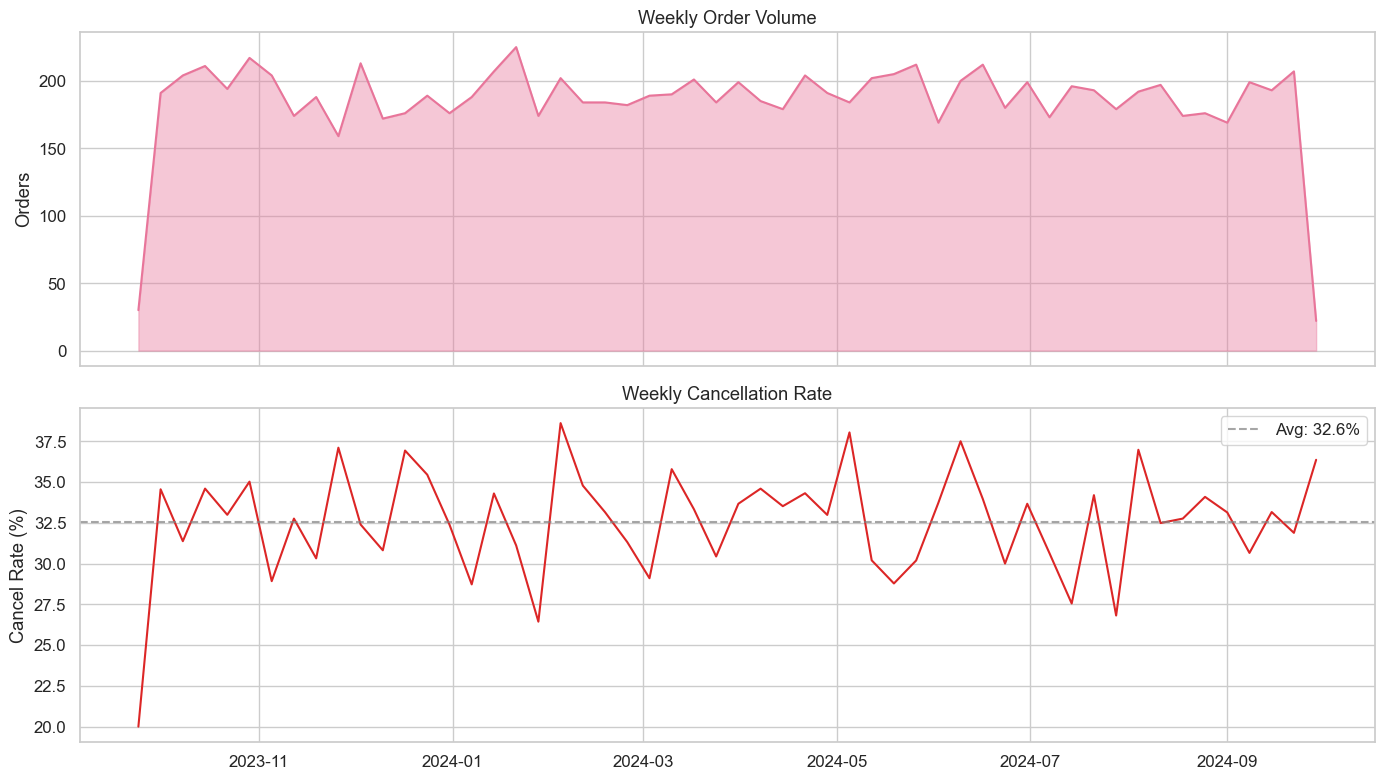

In [17]:
daily = (
    df.set_index("order_date")
    .resample("W")
    .agg(orders=("order_id", "count"), cancellations=("order_status", lambda x: (x == "Cancelled").sum()))
    .reset_index()
)
daily["cancel_rate"] = daily["cancellations"] / daily["orders"] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(daily["order_date"], daily["orders"], alpha=0.4, color="#e8759a")
axes[0].plot(daily["order_date"], daily["orders"], color="#e8759a", linewidth=1.5)
axes[0].set_title("Weekly Order Volume")
axes[0].set_ylabel("Orders")

axes[1].plot(daily["order_date"], daily["cancel_rate"], color="#dc2626", linewidth=1.5)
axes[1].axhline(daily["cancel_rate"].mean(), color="gray", linestyle="--", alpha=0.7,
                label=f"Avg: {daily['cancel_rate'].mean():.1f}%")
axes[1].set_title("Weekly Cancellation Rate")
axes[1].set_ylabel("Cancel Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Key Insights Summary

| Metric | Value |
|--------|-------|
| Total Orders | 9,999 |
| Completion Rate | ~67% |
| Top Revenue Product Type | Office Desk |
| Key Cancellation Drivers | TBD (see charts above) |

**Next Steps:** RFM Analysis & Customer Segmentation → `02_RFM_Analysis.ipynb`